# Pilot benchmark: statistical, supervised and unsupervised fraud detection models
**MScFE 690 Capstone. Explainable machine learning for detecting financial reporting anomalies.**

This notebook is a *pilot*. It runs the three-tier benchmark described in our methodology on the public
dataset of Bao, Ke, Li, Yu and Zhang (2020), which contains Compustat financial data for U.S. firms and
AAER-based fraud labels. The EDGAR/XBRL panel that the full project will build is not used here.

Design choices copied from the methodology:
* one common sample, one common time-based split, one common set of metrics for every model;
* serial fraud handled as in Bao et al. (2020): training years of a case that reaches the test year are recoded to 0;
* headline metrics are PR-AUC and precision in the top decile, with bootstrap confidence intervals;
* SHAP attributions are compared with red-flag variables fixed *before* the SHAP step was run.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import time
import urllib.request
from math import comb

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import xgboost as xgb
import shap
from imblearn.ensemble import RUSBoostClassifier
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

DATA_FILE = "data_FraudDetection_JAR2020.csv"
DATA_URL = "https://raw.githubusercontent.com/JarFraud/FraudDetection/master/" + DATA_FILE
FIG, RES = "figures", "results"
os.makedirs(FIG, exist_ok=True)
os.makedirs(RES, exist_ok=True)

TRAIN_START, GAP = 1991, 2                 # first training year; gap (years) between training and test year
TEST_YEARS = list(range(2003, 2009))       # test window used by Bao et al. (2020)
SEED, N_BOOT = 0, 500
N_JOBS = -1

## 1. Data
Bao et al. (2020) provide 28 raw Compustat items, 14 financial ratios, the label `misstate`
(1 = firm-year covered by an AAER) and `p_aaer`, an identifier of the AAER case used to handle serial fraud.

In [2]:
if not os.path.exists(DATA_FILE):
    urllib.request.urlretrieve(DATA_URL, DATA_FILE)
d = pd.read_csv(DATA_FILE).sort_values(["gvkey", "fyear"]).reset_index(drop=True)

RAW28 = ["act","ap","at","ceq","che","cogs","csho","dlc","dltis","dltt","dp","ib","invt","ivao","ivst",
         "lct","lt","ni","ppegt","pstk","re","rect","sale","sstk","txp","txt","xint","prcc_f"]
RATIOS14 = ["dch_wc","ch_rsst","dch_rec","dch_inv","soft_assets","ch_cs","ch_cm","ch_roa","issue",
            "bm","dpi","reoa","EBIT","ch_fcf"]
F7 = ["ch_rsst","dch_rec","dch_inv","soft_assets","ch_cs","ch_roa","issue"]   # Dechow et al. (2011), model 1 variables
F42 = RAW28 + RATIOS14

print(f"Firm-years: {len(d):,} | firms: {d.gvkey.nunique():,} | fiscal years {d.fyear.min()}-{d.fyear.max()}")
print(f"Fraud firm-years: {int(d.misstate.sum()):,} ({d.misstate.mean():.2%}) | AAER cases: {d.p_aaer.nunique()}")

Firm-years: 146,045 | firms: 18,444 | fiscal years 1990-2014
Fraud firm-years: 964 (0.66%) | AAER cases: 412


## 2. Statistical baselines built from the same data
* **Altman Z** (original 1968 weights), market value of equity = shares x price. Score used for ranking = -Z.
* **Beneish M-score** (1999, eight-variable weights). SG&A is not in the dataset, so SGAI is set to its neutral
  value of 1, which is the convention Beneish applies when SG&A is unavailable. Net PPE is recovered exactly from
  the soft-assets ratio, soft_assets = (at - ppent - che) / at.
* **Dechow F-score (model 1)** is fitted later, inside each training window, as a logistic regression on F7.

In [3]:
d["ppent"] = d["at"] - d["che"] - d["soft_assets"] * d["at"]
d["txp0"] = d["txp"].fillna(0)

def lag(col):
    g = d.groupby("gvkey")
    ok = g["fyear"].shift(1) == (d["fyear"] - 1)
    return g[col].shift(1).where(ok)

for c in ["rect","sale","cogs","act","ppent","at","dp","lct","dltt","che","dlc","txp0"]:
    d["l_" + c] = lag(c)

def clean(s):
    return s.replace([np.inf, -np.inf], np.nan)

dsri = clean((d.rect / d.sale) / (d.l_rect / d.l_sale))
gmi  = clean(((d.l_sale - d.l_cogs) / d.l_sale) / ((d.sale - d.cogs) / d.sale))
aq, aq_l = 1 - (d.act + d.ppent) / d["at"], 1 - (d.l_act + d.l_ppent) / d.l_at
aqi  = clean(aq / aq_l).where(aq_l != 0, 1.0)
aqi  = aqi.where(aq_l.notna() & aq.notna())
sgi  = clean(d.sale / d.l_sale)
depi = clean((d.l_dp / (d.l_dp + d.l_ppent)) / (d.dp / (d.dp + d.ppent)))
depi = depi.where(depi.notna() | d.l_dp.isna(), 1.0)          # undefined rate -> neutral value
lvgi = clean(((d.lct + d.dltt) / d["at"]) / ((d.l_lct + d.l_dltt) / d.l_at))
tata = clean(((d.act - d.l_act) - (d.che - d.l_che) - ((d.lct - d.l_lct) - (d.dlc - d.l_dlc) - (d.txp0 - d.l_txp0)) - d.dp) / d["at"])
idx = pd.DataFrame({"dsri": dsri, "gmi": gmi, "aqi": aqi, "sgi": sgi, "depi": depi, "lvgi": lvgi, "tata": tata})
idx = idx.apply(lambda s: s.clip(s.quantile(.01), s.quantile(.99)))          # winsorise at 1 and 99 percent, as Beneish
d["mscore"] = (-4.84 + 0.920 * idx.dsri + 0.528 * idx.gmi + 0.404 * idx.aqi + 0.892 * idx.sgi
               + 0.115 * idx.depi - 0.172 * 1.0 - 0.327 * idx.lvgi + 4.679 * idx.tata)

mve = d.csho * d.prcc_f
mve = mve.where(mve > 0)
tl = d["lt"].where(d["lt"] > 0)
d["z"] = (1.2 * (d.act - d.lct) / d["at"] + 1.4 * d["re"] / d["at"] + 3.3 * d.EBIT
          + 0.6 * mve / tl + 1.0 * d.sale / d["at"]).replace([np.inf, -np.inf], np.nan)
d["neg_z"] = -d["z"]

## 3. Common sample
Every model is scored on exactly the same firm-years. A firm-year enters the common sample only if all inputs of
all models are available. This is the rule we adopted for the full project, and it removes the confound that
models would otherwise be compared on different observations.

In [4]:
need = F7 + ["mscore", "z"]
base = d[d.fyear >= TRAIN_START]
common = base[need].notna().all(axis=1)
print(f"Firm-years from {TRAIN_START}: {len(base):,}; in common sample: {int(common.sum()):,} "
      f"({common.mean():.1%}); fraud firm-years kept: {int(base.loc[common,'misstate'].sum())} of {int(base.misstate.sum())}")
d["common"] = False
d.loc[base.index[common.values], "common"] = True
drop_tbl = (d[d.fyear >= TRAIN_START].assign(missing_any=lambda x: ~x.common)
            .groupby("fyear").agg(firm_years=("common", "size"), kept=("common", "sum"), frauds=("misstate", "sum")))
drop_tbl.to_csv(os.path.join(RES, "common_sample_by_year.csv"))

Firm-years from 1991: 141,463; in common sample: 107,667 (76.1%); fraud firm-years kept: 798 of 949


## 4. Models and walk-forward evaluation
For every test year t the models are trained on fiscal years 1991 to t-2 (a two-year gap, because fraud is
revealed with a delay) and scored on year t. Training labels of AAER cases that also appear in year t are set to 0.
Hyper-parameters are fixed in this pilot. TimeSeriesSplit tuning is part of the full project.

In [5]:
def metrics(y, s):
    n, P = len(y), int(y.sum())
    o = np.argsort(-s, kind="stable"); ys = y[o]
    out = {"roc_auc": roc_auc_score(y, s), "pr_auc": average_precision_score(y, s), "prevalence": P / n}
    for nm, fr in [("1pct", .01), ("decile", .10)]:
        k = int(round(n * fr)); tp = ys[:k].sum()
        out["prec_" + nm], out["rec_" + nm], out["hits_" + nm] = tp / k, tp / P, int(tp)
    k = int(round(n * .01)); disc = 1 / np.log2(np.arange(2, k + 2))
    out["ndcg_1pct"] = (ys[:k] * disc).sum() / disc[:min(k, P)].sum()
    return out

def make_models(pos, neg):
    return {
        "Logit_F7":   make_pipeline(StandardScaler(), LogisticRegression(C=1e6, max_iter=2000)),
        "RF_F7":      RandomForestClassifier(n_estimators=300, min_samples_leaf=5, class_weight="balanced_subsample",
                                             n_jobs=N_JOBS, random_state=SEED),
        "XGB_F7":     xgb.XGBClassifier(n_estimators=300, learning_rate=.05, max_depth=4, subsample=.8, colsample_bytree=.8,
                                        scale_pos_weight=neg / max(pos, 1), tree_method="hist", n_jobs=N_JOBS, random_state=SEED),
        "RF_F42":     RandomForestClassifier(n_estimators=300, min_samples_leaf=5, class_weight="balanced_subsample",
                                             n_jobs=N_JOBS, random_state=SEED),
        "XGB_F42":    xgb.XGBClassifier(n_estimators=300, learning_rate=.05, max_depth=4, subsample=.8, colsample_bytree=.8,
                                        scale_pos_weight=neg / max(pos, 1), tree_method="hist", n_jobs=N_JOBS, random_state=SEED),
    }

LABELS = {
    "neg_z": "Altman Z-score", "mscore": "Beneish M-score", "Logit_F7": "Dechow F-score (logit, 7 ratios)",
    "RF_F7": "Random Forest (7 ratios)", "XGB_F7": "XGBoost (7 ratios)",
    "RF_F42": "Random Forest (42 variables)", "XGB_F42": "XGBoost (42 variables)",
    "RUS_RAW28": "RUSBoost (28 raw items)", "IF_R14": "Isolation Forest (14 ratios, no labels)",
    "XGB_F42_norecode": "XGBoost (42), no serial-fraud recoding", "XGB_F42_drop": "XGBoost (42), serial-fraud rows dropped",
}
TIER = {"neg_z": "Statistical", "mscore": "Statistical", "Logit_F7": "Statistical",
        "RF_F7": "Supervised ML", "XGB_F7": "Supervised ML", "RF_F42": "Supervised ML", "XGB_F42": "Supervised ML",
        "RUS_RAW28": "Supervised ML", "IF_R14": "Unsupervised", "XGB_F42_norecode": "Robustness", "XGB_F42_drop": "Robustness"}

Y, S, rows, kept_models = {}, {}, [], {}
t0 = time.time()
for t in TEST_YEARS:
    tr = d[d.common & d.fyear.between(TRAIN_START, t - GAP)]
    te = d[d.common & (d.fyear == t)]
    y_te = te.misstate.values.astype(int)
    test_cases = set(te.loc[te.misstate == 1, "p_aaer"].dropna())
    y_tr = tr.misstate.values.astype(int).copy()
    serial = tr.p_aaer.isin(test_cases).values
    n_recoded = int((serial & (y_tr == 1)).sum())
    y_tr_rc = y_tr.copy(); y_tr_rc[serial] = 0
    pos, neg = int(y_tr_rc.sum()), int((y_tr_rc == 0).sum())
    print(f"[{t}] train n={len(tr):,} pos={pos} (recoded {n_recoded}) | test n={len(te):,} pos={int(y_te.sum())}  ({time.time()-t0:.0f}s)")
    Y[t] = y_te; sc = {}
    # closed-form statistical baselines
    sc["neg_z"], sc["mscore"] = te.neg_z.values, te.mscore.values
    # fitted models
    models = make_models(pos, neg)
    for nm, m in models.items():
        cols = F7 if nm.endswith("F7") else F42
        m.fit(tr[cols], y_tr_rc)
        sc[nm] = m.predict_proba(te[cols])[:, 1]
    kept_models[t] = (models, te)
    # RUSBoost on 28 raw items, as in Bao et al. (2020)
    rus = RUSBoostClassifier(estimator=DecisionTreeClassifier(min_samples_leaf=5), n_estimators=300,
                             learning_rate=.1, random_state=SEED)
    rus.fit(tr[RAW28], y_tr_rc); sc["RUS_RAW28"] = rus.predict_proba(te[RAW28])[:, 1]
    # unsupervised: no labels used at any point
    med = tr[RATIOS14].median()
    iso = IsolationForest(n_estimators=500, random_state=SEED, n_jobs=N_JOBS).fit(tr[RATIOS14].fillna(med))
    sc["IF_R14"] = -iso.score_samples(te[RATIOS14].fillna(med))
    # robustness: serial fraud treatments
    pos_n, neg_n = int(y_tr.sum()), int((y_tr == 0).sum())
    m = make_models(pos_n, neg_n)["XGB_F42"].fit(tr[F42], y_tr); sc["XGB_F42_norecode"] = m.predict_proba(te[F42])[:, 1]
    keep = ~serial
    m = make_models(int(y_tr[keep].sum()), int((y_tr[keep] == 0).sum()))["XGB_F42"].fit(tr.loc[keep, F42], y_tr[keep])
    sc["XGB_F42_drop"] = m.predict_proba(te[F42])[:, 1]
    S[t] = sc
    for nm, s in sc.items():
        rows.append({"test_year": t, "model": nm, "n_test": len(te), "n_pos": int(y_te.sum()), "recoded_train_pos": n_recoded,
                     **metrics(y_te, np.asarray(s, float))})
by_year = pd.DataFrame(rows); by_year["label"] = by_year.model.map(LABELS); by_year["tier"] = by_year.model.map(TIER)
by_year.to_csv(os.path.join(RES, "metrics_by_test_year.csv"), index=False)
print(f"Done in {time.time()-t0:.0f}s")

[2003] train n=52,121 pos=327 (recoded 77) | test n=4,660 pos=61  (0s)


[2004] train n=56,843 pos=374 (recoded 96) | test n=4,595 pos=49  (69s)


[2005] train n=61,503 pos=439 (recoded 92) | test n=4,518 pos=44  (141s)


[2006] train n=66,098 pos=546 (recoded 34) | test n=4,451 pos=26  (219s)


[2007] train n=70,616 pos=600 (recoded 24) | test n=4,392 pos=26  (311s)


[2008] train n=75,067 pos=633 (recoded 17) | test n=4,332 pos=22  (413s)


Done in 523s


## 5. Bootstrap confidence intervals
Within every test year firm-years are resampled with replacement, the same draw for all models, so differences
between models are paired. Each replicate averages the yearly metric over the six test years, as in Bao et al.

In [6]:
mods = list(LABELS)
rng = np.random.default_rng(SEED)
mnames = ["roc_auc", "pr_auc", "prec_decile", "rec_decile"]
boot = {m: {k: np.zeros(N_BOOT) for k in mnames} for m in mods}
for b in range(N_BOOT):
    acc = {m: {k: 0.0 for k in mnames} for m in mods}
    for t in TEST_YEARS:
        n = len(Y[t]); ii = rng.integers(0, n, n); yb = Y[t][ii]
        k = int(round(n * .10)); P = yb.sum()
        for m in mods:
            s = np.asarray(S[t][m], float)[ii]
            o = np.argsort(-s, kind="stable"); tp = yb[o][:k].sum()
            acc[m]["roc_auc"] += roc_auc_score(yb, s); acc[m]["pr_auc"] += average_precision_score(yb, s)
            acc[m]["prec_decile"] += tp / k; acc[m]["rec_decile"] += tp / P
    for m in mods:
        for kx in mnames:
            boot[m][kx][b] = acc[m][kx] / len(TEST_YEARS)

summ = []
for m in mods:
    g = by_year[by_year.model == m]
    r = {"model": m, "label": LABELS[m], "tier": TIER[m]}
    for kx in ["roc_auc", "pr_auc", "prec_1pct", "prec_decile", "rec_decile", "ndcg_1pct"]:
        r[kx] = g[kx].mean()
    for kx in mnames:
        r[kx + "_lo"], r[kx + "_hi"] = np.percentile(boot[m][kx], [2.5, 97.5])
    summ.append(r)
summ = pd.DataFrame(summ)
prev = by_year[by_year.model == "neg_z"].prevalence.mean()
summ["prevalence_baseline"] = prev
summ.to_csv(os.path.join(RES, "summary_metrics.csv"), index=False)

pairs = [("Algorithm effect, same 7 inputs: XGBoost minus Dechow F-score", "XGB_F7", "Logit_F7"),
         ("Algorithm effect, same 7 inputs: Random Forest minus Dechow F-score", "RF_F7", "Logit_F7"),
         ("Input effect, same algorithm: XGBoost (42) minus XGBoost (7)", "XGB_F42", "XGB_F7"),
         ("Combined effect: XGBoost (42) minus Dechow F-score", "XGB_F42", "Logit_F7"),
         ("Combined effect: XGBoost (42) minus Beneish M-score", "XGB_F42", "mscore"),
         ("Combined effect: XGBoost (42) minus Altman Z-score", "XGB_F42", "neg_z"),
         ("Bao et al. comparison: RUSBoost (28 raw) minus Dechow F-score", "RUS_RAW28", "Logit_F7"),
         ("Combined effect: Random Forest (42) minus Dechow F-score", "RF_F42", "Logit_F7"),
         ("Unsupervised minus Dechow F-score", "IF_R14", "Logit_F7"),
         ("Serial-fraud recoding minus no recoding (XGBoost 42)", "XGB_F42", "XGB_F42_norecode")]
pr = []
for lab, a, b_ in pairs:
    r = {"comparison": lab}
    for kx in ["roc_auc", "pr_auc", "prec_decile"]:
        diff = boot[a][kx] - boot[b_][kx]
        r[kx + "_diff"] = summ.set_index("model").loc[a, kx] - summ.set_index("model").loc[b_, kx]
        r[kx + "_lo"], r[kx + "_hi"] = np.percentile(diff, [2.5, 97.5])
    pr.append(r)
pr = pd.DataFrame(pr); pr.to_csv(os.path.join(RES, "paired_differences.csv"), index=False)
pd.set_option("display.width", 220, "display.max_columns", 30)
print(summ[["label", "roc_auc", "pr_auc", "prec_1pct", "prec_decile", "rec_decile"]].round(3).to_string(index=False))
print("mean prevalence in test years:", round(prev, 4))
print(pr.round(3).to_string(index=False))

                                  label  roc_auc  pr_auc  prec_1pct  prec_decile  rec_decile
                         Altman Z-score    0.375   0.006      0.000        0.001       0.014
                        Beneish M-score    0.557   0.010      0.000        0.008       0.104
       Dechow F-score (logit, 7 ratios)    0.652   0.018      0.034        0.015       0.183
               Random Forest (7 ratios)    0.638   0.016      0.026        0.015       0.185
                     XGBoost (7 ratios)    0.642   0.026      0.022        0.016       0.198
           Random Forest (42 variables)    0.669   0.016      0.011        0.015       0.165
                 XGBoost (42 variables)    0.663   0.017      0.022        0.018       0.199
                RUSBoost (28 raw items)    0.684   0.017      0.018        0.018       0.198
Isolation Forest (14 ratios, no labels)    0.451   0.007      0.000        0.004       0.065
 XGBoost (42), no serial-fraud recoding    0.729   0.031      0.055   

## 6. Replication check against Bao et al. (2020)
Bao et al. report an average AUC of about 0.725 for RUSBoost on 28 raw items over 2003 to 2008, using their full
Compustat sample. We repeat the exercise on the full sample, without our common-sample restriction. A result
close to theirs shows that the pipeline is sound.

In [7]:
rep = []
for t in TEST_YEARS:
    tr = d[d.fyear.between(TRAIN_START, t - GAP)]; te = d[d.fyear == t]
    y_tr = tr.misstate.values.astype(int).copy()
    cases = set(te.loc[te.misstate == 1, "p_aaer"].dropna()); y_tr[tr.p_aaer.isin(cases).values] = 0
    m = RUSBoostClassifier(estimator=DecisionTreeClassifier(min_samples_leaf=5), n_estimators=300, learning_rate=.1,
                           random_state=SEED).fit(tr[RAW28], y_tr)
    rep.append({"test_year": t, "n_test": len(te), "n_pos": int(te.misstate.sum()),
                **metrics(te.misstate.values.astype(int), m.predict_proba(te[RAW28])[:, 1])})
rep = pd.DataFrame(rep); rep.to_csv(os.path.join(RES, "replication_rusboost_full_sample.csv"), index=False)
print(rep[["test_year", "n_test", "n_pos", "roc_auc", "hits_1pct", "prec_1pct", "ndcg_1pct"]].round(3).to_string(index=False))
print("Replication, average over 2003-2008: precision top 1% =", round(rep.prec_1pct.mean(), 4), "| NDCG@1% =", round(rep.ndcg_1pct.mean(), 4),
      "| frauds in top 1% (total) =", int(rep.hits_1pct.sum()), "| Bao et al. (2020) report precision 4.48%, NDCG@k 0.049, 16 frauds in total")
print("Average AUC, replication:", round(rep.roc_auc.mean(), 3), "| Bao et al. (2020) report about 0.725")

 test_year  n_test  n_pos  roc_auc  hits_1pct  prec_1pct  ndcg_1pct
      2003    5981     69    0.719          4      0.067      0.050
      2004    5934     58    0.764          1      0.017      0.018
      2005    5863     45    0.714          1      0.017      0.014
      2006    5908     33    0.765          0      0.000      0.000
      2007    5868     30    0.684          0      0.000      0.000
      2008    5612     26    0.637          1      0.018      0.025
Replication, average over 2003-2008: precision top 1% = 0.0197 | NDCG@1% = 0.0178 | frauds in top 1% (total) = 7 | Bao et al. (2020) report precision 4.48%, NDCG@k 0.049, 16 frauds in total
Average AUC, replication: 0.714 | Bao et al. (2020) report about 0.725


## 7. Explainability: SHAP against pre-specified red flags
The red-flag list below was written down **before** SHAP values were computed. It follows the forensic
accounting literature summarised in our review: abnormal accruals, receivables growing faster than sales,
deteriorating margins, a high share of soft assets, rapid sales growth and reliance on external financing.

In [8]:
RED_FLAGS = ["ch_rsst", "dch_wc", "dch_rec", "ch_cm", "soft_assets", "ch_cs", "issue", "sstk", "dltis"]
t_s = TEST_YEARS[-1]
models_s, te_s = kept_models[t_s]
shap_out = {}
for nm, cols in [("XGB_F42", F42), ("XGB_F7", F7)]:
    sv = shap.TreeExplainer(models_s[nm]).shap_values(te_s[cols])
    imp = pd.Series(np.abs(sv).mean(axis=0), index=cols).sort_values(ascending=False)
    shap_out[nm] = imp
    imp.rename("mean_abs_shap").to_frame().assign(red_flag=lambda x: x.index.isin(RED_FLAGS)).to_csv(
        os.path.join(RES, f"shap_importance_{nm}_test{t_s}.csv"))
imp = shap_out["XGB_F42"]; top10 = list(imp.index[:10]); hits = [f for f in top10 if f in RED_FLAGS]
M, K, N = len(RED_FLAGS), 10, len(F42)
expected = K * M / N
pval = sum(comb(M, j) * comb(N - M, K - j) for j in range(len(hits), min(K, M) + 1)) / comb(N, K)
print(f"XGBoost (42 variables), test year {t_s}: top 10 by mean |SHAP| = {top10}")
print(f"Red flags in top 10: {len(hits)} {hits} | expected by chance {expected:.2f} | hypergeometric P(X>={len(hits)}) = {pval:.3f}")
print("Top 7 for XGBoost (7 ratios):", list(shap_out['XGB_F7'].index))

XGBoost (42 variables), test year 2008: top 10 by mean |SHAP| = ['soft_assets', 'sstk', 'reoa', 'prcc_f', 'ceq', 'ap', 'bm', 'act', 'ppegt', 'at']
Red flags in top 10: 2 ['soft_assets', 'sstk'] | expected by chance 2.14 | hypergeometric P(X>=2) = 0.701
Top 7 for XGBoost (7 ratios): ['soft_assets', 'ch_cs', 'issue', 'ch_rsst', 'dch_inv', 'dch_rec', 'ch_roa']


## 8. Figures

In [9]:
INK, INK2, SURF, GRID = "#0b0b0b", "#52514e", "#fcfcfb", "#e6e5e1"
COL = {"Statistical": "#2a78d6", "Supervised ML": "#eb6834", "Unsupervised": "#1baf7a", "Robustness": "#8a8985"}
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 10, "axes.edgecolor": GRID, "axes.labelcolor": INK2,
                     "xtick.color": INK2, "ytick.color": INK, "text.color": INK, "figure.facecolor": SURF,
                     "axes.facecolor": SURF, "axes.spines.top": False, "axes.spines.right": False})

# Figure 1: label timing in the full dataset
yr = d[d.fyear >= 1991].groupby("fyear").agg(n=("misstate", "size"), pos=("misstate", "sum"))
fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
for a in ax:
    a.axvspan(TEST_YEARS[0] - .5, TEST_YEARS[-1] + .5, color=GRID, alpha=.8, lw=0); a.grid(axis="y", color=GRID, lw=.8)
ax[0].bar(yr.index, yr.pos, color=COL["Statistical"], width=.7)
ax[0].set_ylabel("Fraud firm-years (count)")
ax[1].plot(yr.index, 100 * yr.pos / yr.n, color=COL["Supervised ML"], lw=2, marker="o", ms=4)
ax[1].set_ylabel("Share of firm-years (%)"); ax[1].set_xlabel("Fiscal year"); ax[1].set_ylim(bottom=0)
ax[0].text(TEST_YEARS[0] - .3, ax[0].get_ylim()[1] * .92, "test years 2003 to 2008", color=INK2, fontsize=9)
ax[1].annotate("fewer labels in recent years", xy=(2013, 100 * yr.loc[2013, "pos"] / yr.loc[2013, "n"]),
               xytext=(2009.3, 0.95), color=INK2, fontsize=9, arrowprops=dict(arrowstyle="-", color=INK2, lw=.8))
fig.tight_layout(); fig.savefig(os.path.join(FIG, "fig1_labels_by_year.png"), dpi=200); plt.close(fig)

# Figure 2: performance by model with bootstrap intervals
show = [m for m in mods if TIER[m] != "Robustness"]
panels = [("roc_auc", "ROC-AUC", None), ("pr_auc", "PR-AUC", prev), ("rec_decile", "Share of frauds in top decile", .10)]
fig, axs = plt.subplots(1, 3, figsize=(13, 4.8), sharey=True)
ypos = np.arange(len(show))[::-1]
for a, (kx, ttl, base_) in zip(axs, panels):
    for yp, m in zip(ypos, show):
        r = summ.set_index("model").loc[m]
        a.errorbar(r[kx], yp, xerr=[[r[kx] - r[kx + "_lo"]], [r[kx + "_hi"] - r[kx]]], fmt="o", color=COL[TIER[m]], ms=6,
                   elinewidth=1.6, capsize=0, mec=SURF, mew=1.2)
    if base_ is not None:
        a.axvline(base_, color=INK2, lw=1, ls="--"); a.text(base_, len(show) - .35, " baseline", color=INK2, fontsize=8, va="bottom")
    if kx == "roc_auc":
        a.axvline(.5, color=INK2, lw=1, ls="--"); a.text(.5, len(show) - .35, " chance", color=INK2, fontsize=8, va="bottom")
    a.set_xlabel(ttl + " (mean, 6 test years)"); a.grid(axis="x", color=GRID, lw=.8)
axs[0].set_yticks(ypos); axs[0].set_yticklabels([LABELS[m] for m in show])
handles = [plt.Line2D([], [], marker="o", ls="", color=c, label=k) for k, c in COL.items() if k != "Robustness"]
fig.legend(handles=handles, loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(.55, -.01))
fig.tight_layout(rect=(0, .05, 1, 1)); fig.savefig(os.path.join(FIG, "fig2_model_performance.png"), dpi=200); plt.close(fig)

# Figure 3: SHAP
top = shap_out["XGB_F42"].head(12)[::-1]
fig, a = plt.subplots(figsize=(8, 5))
cols_ = [COL["Statistical"] if f in RED_FLAGS else "#8a8985" for f in top.index]
a.barh(range(len(top)), top.values, color=cols_, height=.62)
a.set_yticks(range(len(top))); a.set_yticklabels([f + ("  (red flag)" if f in RED_FLAGS else "") for f in top.index])
a.set_xlabel(f"Mean absolute SHAP value (log-odds), test year {t_s}"); a.grid(axis="x", color=GRID, lw=.8)
a.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=COL["Statistical"]), plt.Rectangle((0, 0), 1, 1, color="#8a8985")],
         labels=["Pre-specified red flag", "Other variable"], frameon=False, loc="lower right")
fig.tight_layout(); fig.savefig(os.path.join(FIG, "fig3_shap_top_features.png"), dpi=200); plt.close(fig)
print(f"Figures saved in the '{FIG}' folder")

Figures saved in the 'figures' folder


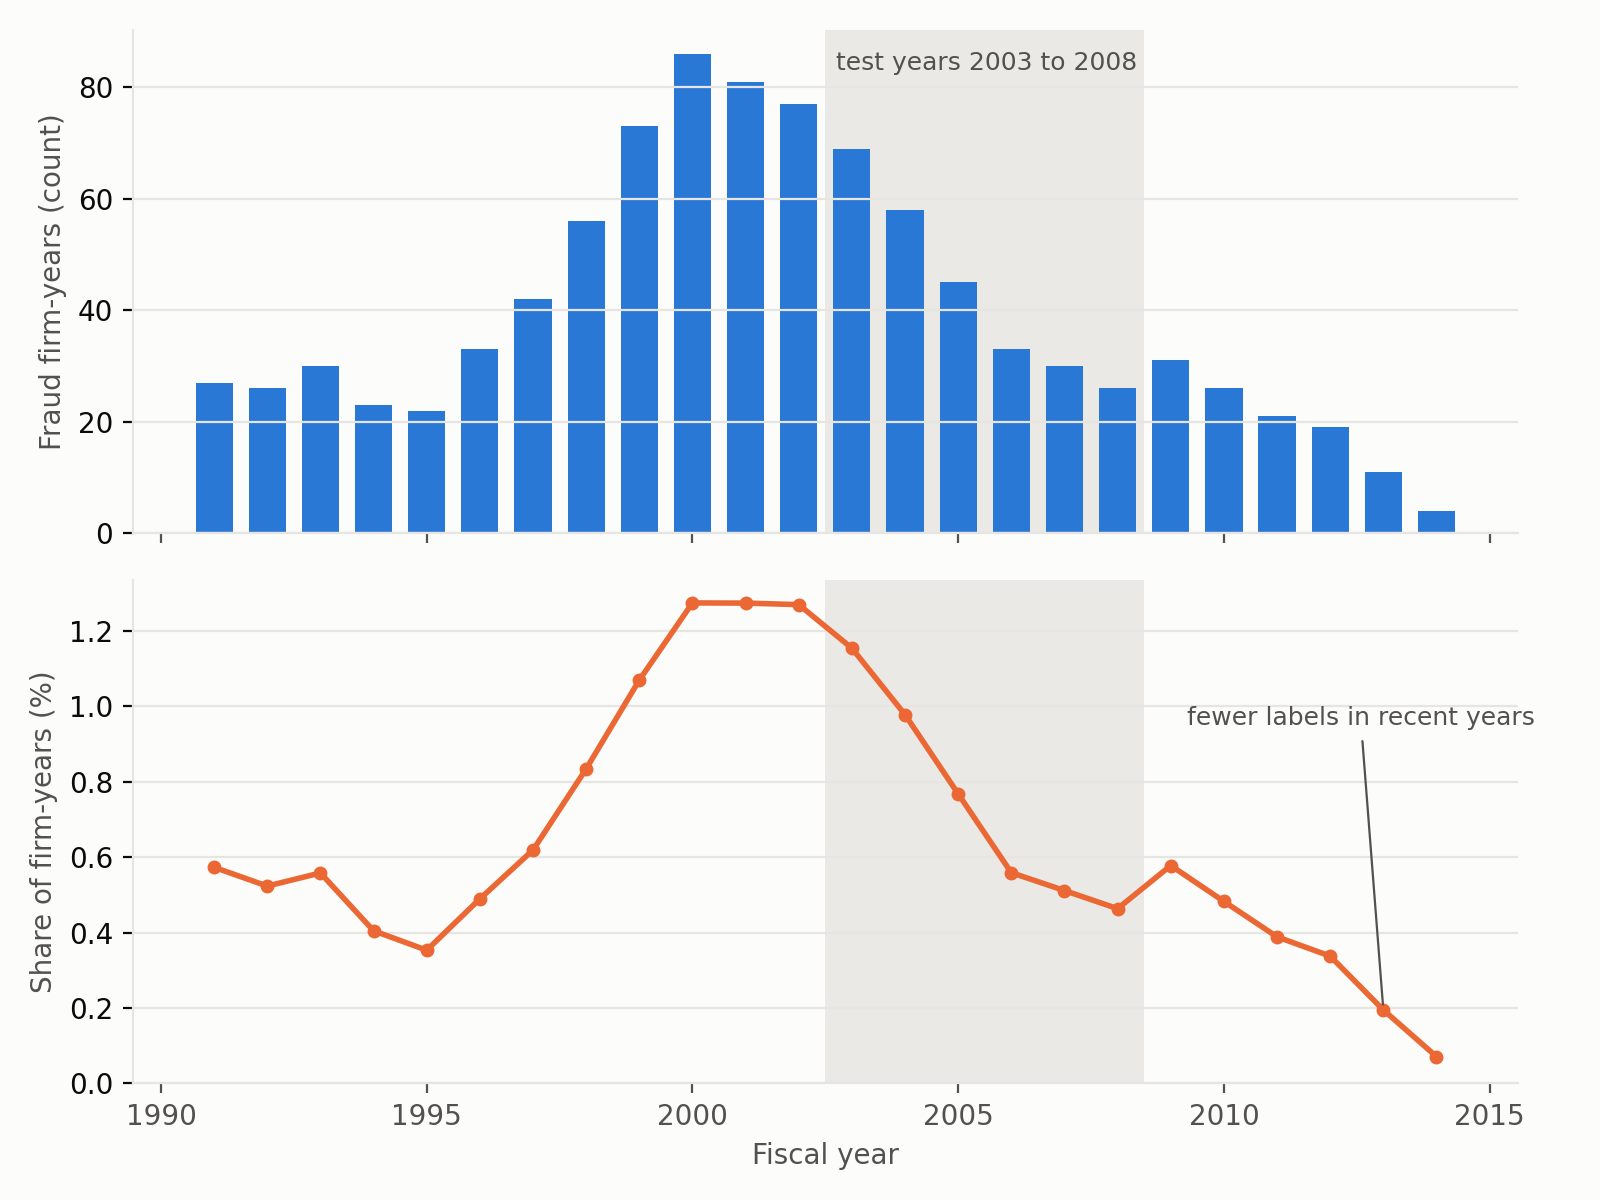

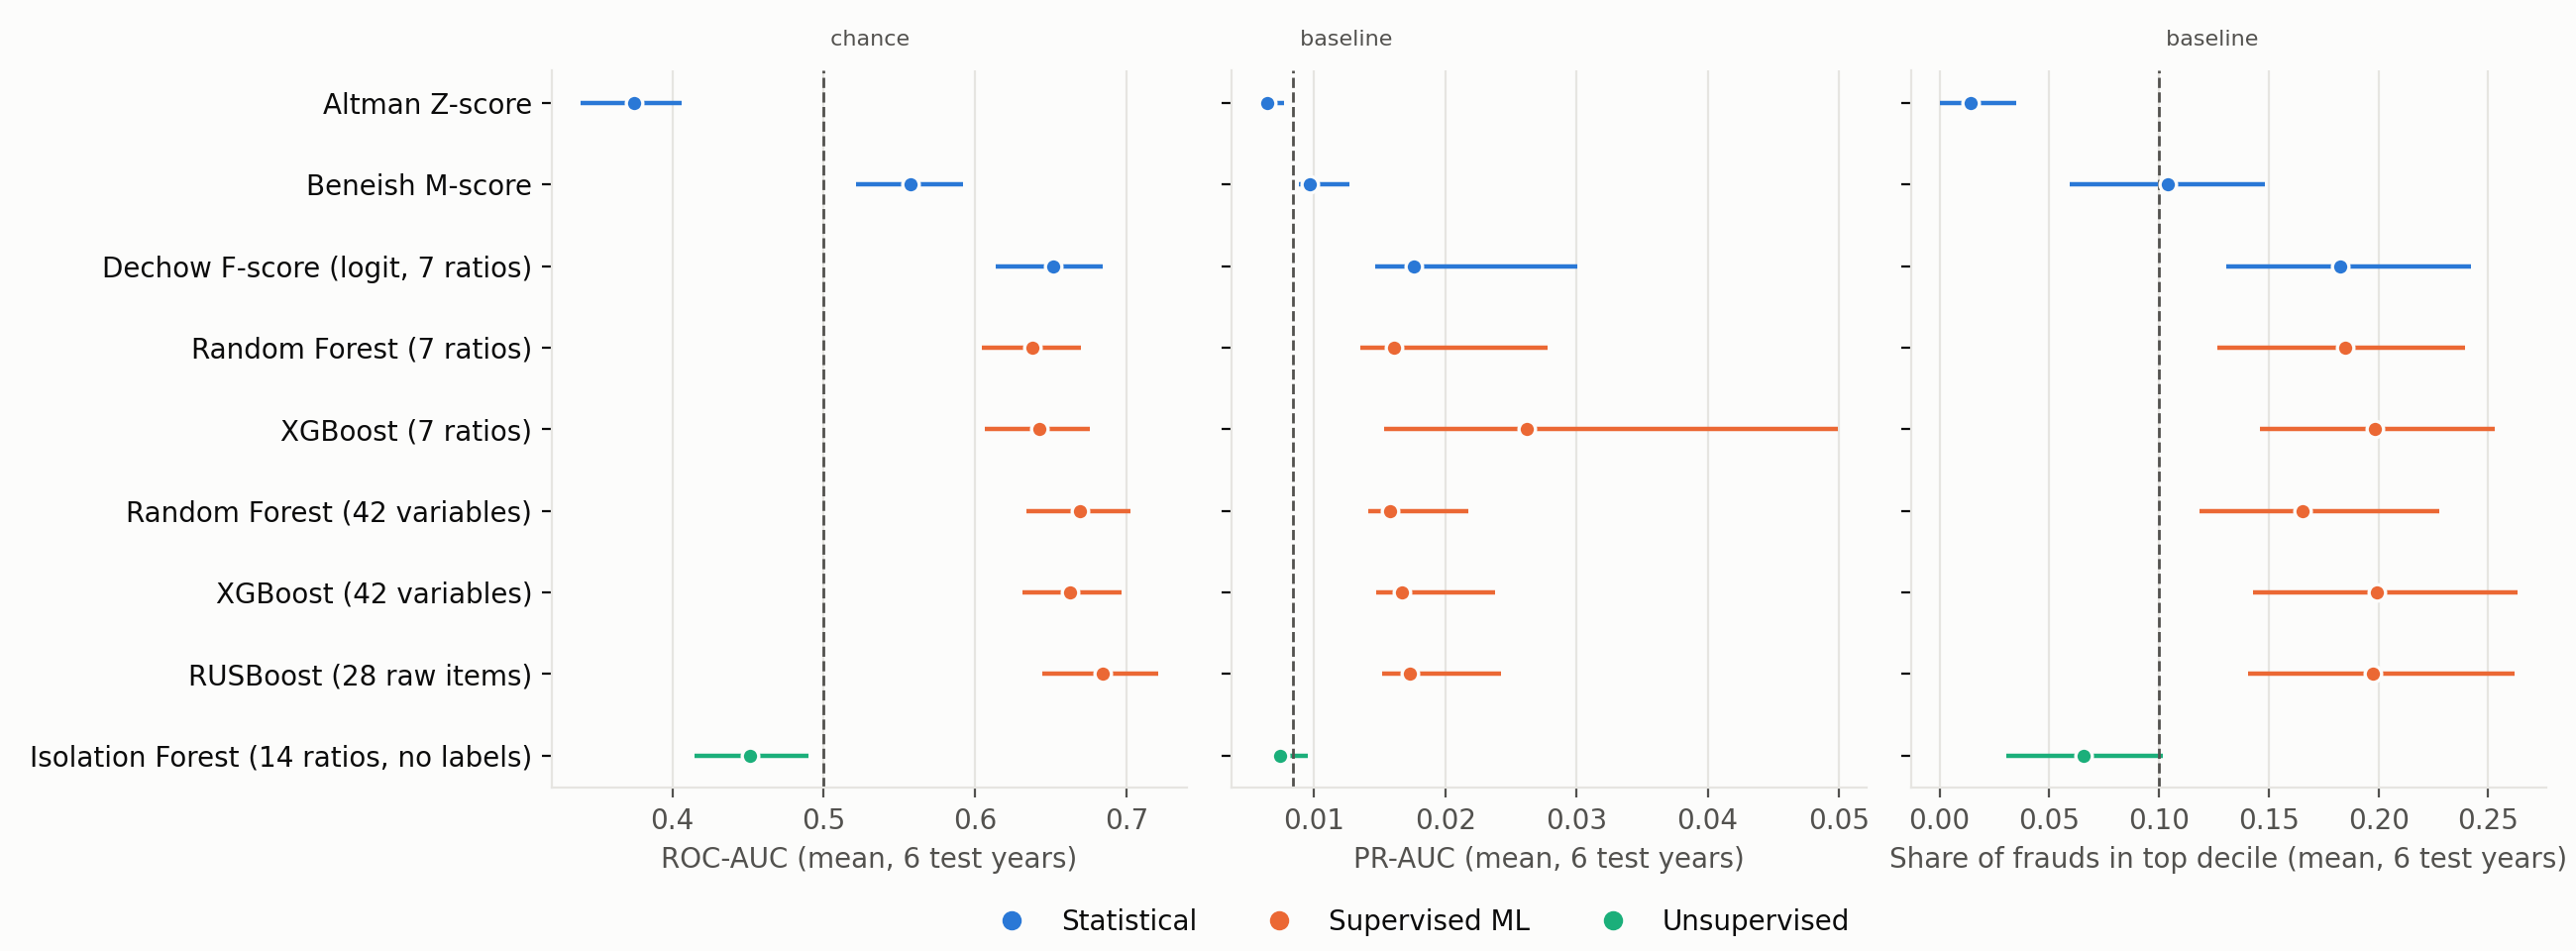

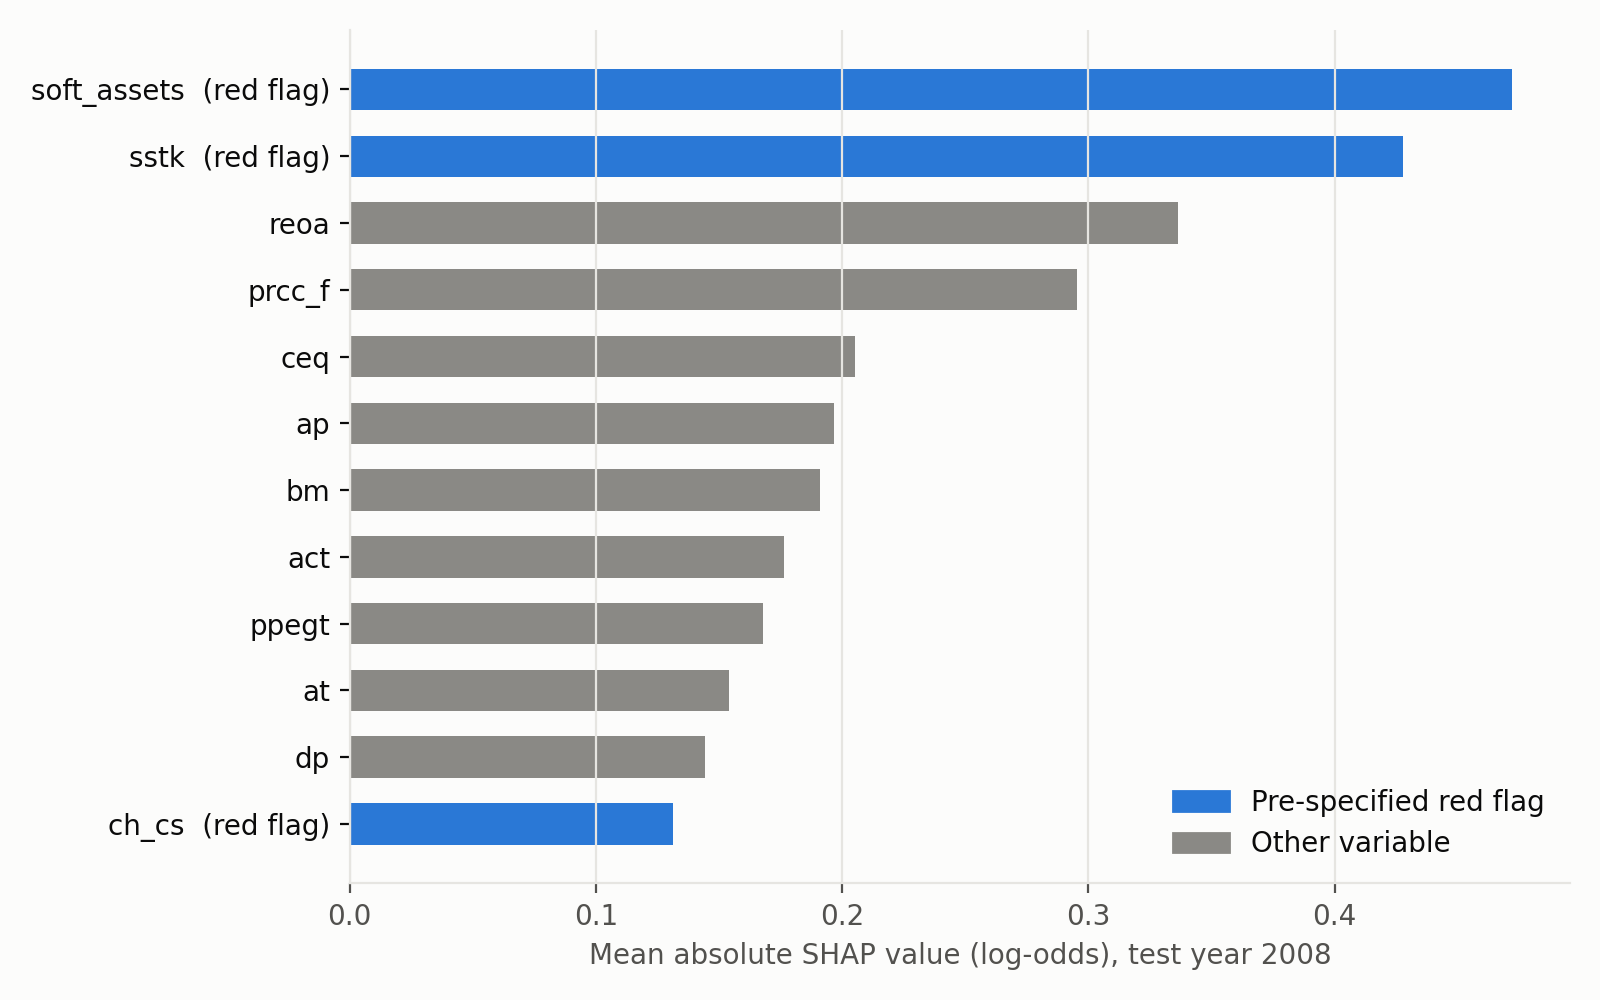

In [10]:
try:
    from IPython.display import Image, display
    for f in ["fig1_labels_by_year.png", "fig2_model_performance.png", "fig3_shap_top_features.png"]:
        display(Image(filename=os.path.join(FIG, f)))
except Exception:
    pass